# DE vs IT Cross-Market Comparison — Audi Q4 e-tron

Compares the **Germany (DE)** rolling lifecycle dataset (Apr 23 – May 14 2026, 2,517 listings)
against the **Italy (IT)** one-time snapshot.

**Important scoping note:** Italy has no lifecycle data (no sold/removed events, no duration_days).
The comparison is strictly cross-sectional: listing characteristics, prices, model mix,
feature penetration, and market structure.  Sale velocity is excluded.

## Sections
1. Data Loading
2. Market Overview Table
3. Price Distribution Comparison
4. Model Mix & Trim Comparison
5. Mileage & Age Comparison
6. Seller Profile Comparison
7. Feature Completeness & Data Quality
8. Price Driver Correlation Comparison
9. Cross-Market Price Positioning (DE model → IT listings)
10. Summary Dashboard

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import joblib

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Set2", font_scale=1.1)
PALETTE = {"DE": "#2196F3", "IT": "#FF5722"}

# Paths
DE_PATH          = Path("../../Preprocessing/outputs/audi_q4_lifecycle_clean.parquet")
IT_PATH          = Path("../Preprocessing/outputs/audi_q4_it_snapshot_clean.parquet")
PRICE_MODEL_PATH = Path("../../Models/saved_models/price_model_best1.pkl")
PRICE_META_PATH  = Path("../../Models/saved_models/price_model_meta.json")

print("Loading datasets...")
df_de = pd.read_parquet(DE_PATH); df_de["market"] = "DE"
df_it = pd.read_parquet(IT_PATH); df_it["market"] = "IT"

# --- Backfill engineered columns that only exist in the ML datasets, not lifecycle_clean ---
_de_text = (df_de["title"].fillna("") + " " + df_de["subtitle"].fillna("")).str.lower()
df_de["model_number_v2"] = _de_text.str.extract(
    r"(?:q4\s*)?(35|40|45|50|55)\s*(?:e[- ]?tron|quattro|qu\.|\b)", expand=False
).fillna(_de_text.str.extract(r"\b(35|40|45|50|55)\b", expand=False))
df_de["price_per_kw"]       = df_de["price_eur"] / pd.to_numeric(df_de["power_kw"], errors="coerce")
df_de["price_per_hp"]       = df_de["price_eur"] / pd.to_numeric(df_de["power_hp"], errors="coerce")
df_de["price_per_range_km"] = df_de["price_eur"] / df_de["electric_range_km"] if "electric_range_km" in df_de.columns else np.nan
df_de["mileage_per_month"]  = df_de["mileage_km"] / df_de["vehicle_age_months"].replace(0, np.nan)
df_de["seller_has_rating"]  = df_de["seller_rating_stars"].notna().astype(int)
for _col, _flag in [("warranty_months","has_warranty_months"),
                    ("battery_charging_time_min","has_charging_time"),
                    ("electric_range_city_km","has_city_range"),
                    ("battery_ownership","has_battery_info")]:
    df_de[_flag] = df_de[_col].notna().astype(int) if _col in df_de.columns else 0

# Shared listing-characteristic columns (no lifecycle/survival columns)
SHARED_COLS = [
    "listing_id", "title", "subtitle", "variant", "model_number_v2",
    "price_eur", "mileage_km", "vehicle_age_months", "power_kw", "power_hp",
    "electric_range_km", "wltp_consumption_kwh_100km", "wltp_co2_g_km",
    "seller_type", "seller_rating_stars", "seller_rating_count",
    "image_count", "previous_owner_count", "door_count", "seat_count",
    "warranty_months", "battery_charging_time_min",
    "body_type", "exterior_color", "paint_type", "interior_color", "upholstery_material",
    "city",
    "is_sportback", "is_quattro", "is_s_line", "has_matrix", "has_pano",
    "has_ahk", "has_hud", "has_acc", "has_camera",
    "is_conditional_price_clean", "available_now_clean", "warranty_exists_clean",
    "has_full_service_history_clean", "had_accident_clean",
    "duplicate_listing_id", "seller_has_rating", "has_warranty_months",
    "has_battery_info", "has_city_range", "has_charging_time",
    "price_per_kw", "price_per_hp", "price_per_range_km", "mileage_per_month",
    "market",
]

available_cols = [c for c in SHARED_COLS if c in df_de.columns and c in df_it.columns]
missing = [c for c in SHARED_COLS if c not in available_cols]
if missing:
    print(f"Columns not available in both datasets (skipped): {missing}")

df_de_cs = df_de[available_cols].copy()
df_it_cs = df_it[available_cols].copy()
df = pd.concat([df_de_cs, df_it_cs], ignore_index=True)

print(f"DE listings: {len(df_de_cs):,}  |  IT listings: {len(df_it_cs):,}  |  Combined: {len(df):,}")
print(f"Shared columns: {len(available_cols)}")


Loading datasets...
DE listings: 2,517  |  IT listings: 227  |  Combined: 2,744
Shared columns: 53


## Section 2 — Market Overview Table

In [2]:
def pct_share(series, value):
    return f"{(series == value).mean():.1%}"

def median_fmt(series, fmt="{:,.0f}"):
    v = series.median()
    return fmt.format(v) if pd.notna(v) else "N/A"

overview_data = {}
for market, df_m in [("DE", df_de_cs), ("IT", df_it_cs)]:
    overview_data[market] = {
        "Total listings":          f"{len(df_m):,}",
        "Unique listing IDs":       f"{df_m['listing_id'].nunique():,}",
        "Median price (€)":         median_fmt(df_m["price_eur"]),
        "Median mileage (km)":      median_fmt(df_m["mileage_km"]),
        "Median vehicle age (mo)": median_fmt(df_m["vehicle_age_months"]),
        "Median power (kW)":        median_fmt(df_m["power_kw"]),
        "Dealer share":             pct_share(df_m["seller_type"], "Dealer"),
        "Sportback share":          f"{df_m['is_sportback'].mean():.1%}",
        "Quattro share":            f"{df_m['is_quattro'].mean():.1%}",
        "S-Line share":             f"{df_m['is_s_line'].mean():.1%}",
        "Had accident share":       f"{df_m['had_accident_clean'].mean():.1%}" if 'had_accident_clean' in df_m else "N/A",
    }

overview_df = pd.DataFrame(overview_data)
overview_df.index.name = "Metric"
print(overview_df.to_string())
overview_df

                             DE      IT
Metric                                 
Total listings            2,517     227
Unique listing IDs        2,389     227
Median price (€)         37,500  41,500
Median mileage (km)      26,934  25,560
Median vehicle age (mo)      36      30
Median power (kW)           195      77
Dealer share              98.3%   85.5%
Sportback share           33.7%   36.1%
Quattro share             19.1%   21.1%
S-Line share              30.6%   40.5%
Had accident share         0.0%    0.0%


,DE,IT
Metric,,
Total listings,"2,517",227
Unique listing IDs,"2,389",227
Median price (€),"37,500","41,500"
Median mileage (km),"26,934","25,560"
Median vehicle age (mo),36,30
Median power (kW),195,77
Dealer share,98.3%,85.5%
Sportback share,33.7%,36.1%
Quattro share,19.1%,21.1%


## Section 3 — Price Distribution Comparison

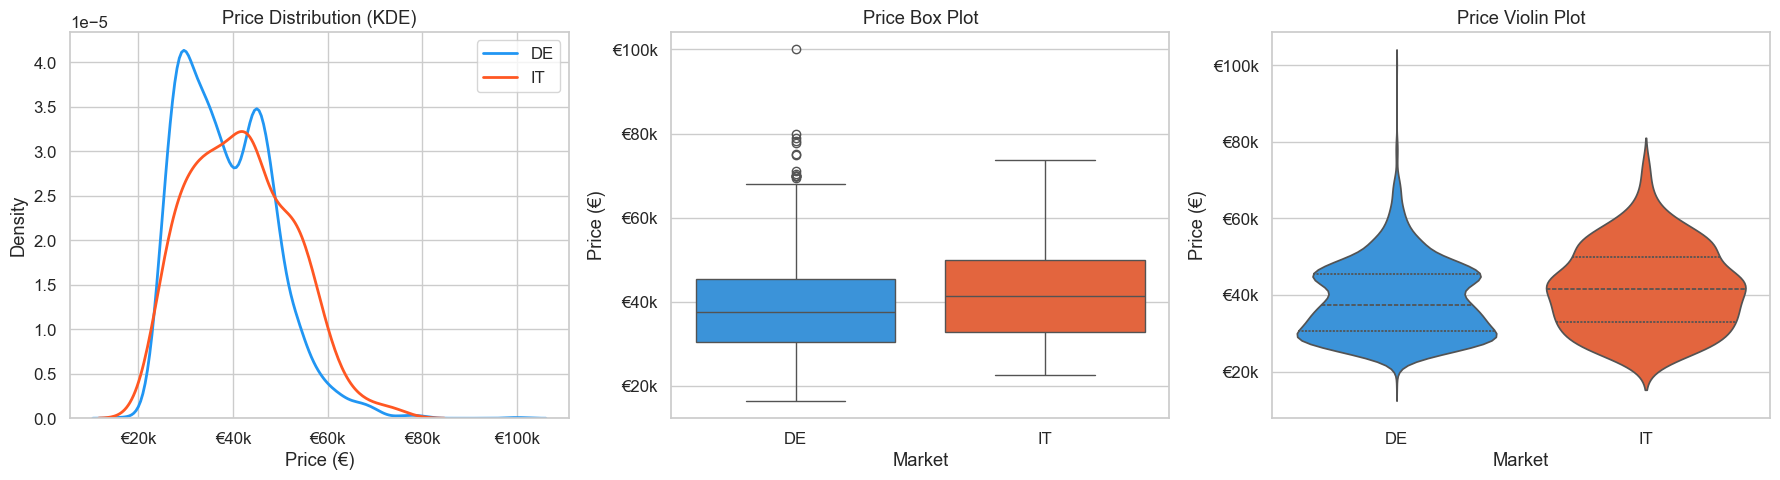

Saved: price_distribution_de_vs_it.png


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# KDE overlay
for market, df_m in [("DE", df_de_cs), ("IT", df_it_cs)]:
    prices = df_m["price_eur"].dropna()
    sns.kdeplot(prices, ax=axes[0], label=market, color=PALETTE[market], linewidth=2)
axes[0].set(title="Price Distribution (KDE)", xlabel="Price (€)", ylabel="Density")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"€{x/1000:.0f}k"))
axes[0].legend()

# Box plot
df_price = df[["price_eur", "market"]].dropna()
sns.boxplot(data=df_price, x="market", y="price_eur", palette=PALETTE, ax=axes[1],
            order=["DE", "IT"])
axes[1].set(title="Price Box Plot", xlabel="Market", ylabel="Price (€)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"€{x/1000:.0f}k"))

# Violin plot
sns.violinplot(data=df_price, x="market", y="price_eur", palette=PALETTE, ax=axes[2],
               order=["DE", "IT"], inner="quartile")
axes[2].set(title="Price Violin Plot", xlabel="Market", ylabel="Price (€)")
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"€{x/1000:.0f}k"))

plt.tight_layout()
plt.savefig("price_distribution_de_vs_it.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: price_distribution_de_vs_it.png")

In [4]:
# Statistical tests
de_prices = df_de_cs["price_eur"].dropna().values
it_prices = df_it_cs["price_eur"].dropna().values

t_stat, t_pval = stats.ttest_ind(de_prices, it_prices, equal_var=False)  # Welch
u_stat, u_pval = stats.mannwhitneyu(de_prices, it_prices, alternative="two-sided")

# Cohen's d
pooled_std = np.sqrt((de_prices.std()**2 + it_prices.std()**2) / 2)
cohens_d = (de_prices.mean() - it_prices.mean()) / pooled_std

print("Price Statistical Tests")
print(f"  Welch t-test:     t={t_stat:.3f}, p={t_pval:.4f}")
print(f"  Mann-Whitney U:   U={u_stat:.0f}, p={u_pval:.4f}")
print(f"  Cohen's d:        {cohens_d:.3f} ({'large' if abs(cohens_d)>0.8 else 'medium' if abs(cohens_d)>0.5 else 'small'} effect)")
print()

# Percentile table
pcts = [10, 25, 50, 75, 90]
pct_table = pd.DataFrame({
    "DE": np.percentile(de_prices, pcts),
    "IT": np.percentile(it_prices, pcts),
}, index=[f"p{p}" for p in pcts])
pct_table["IT - DE"] = pct_table["IT"] - pct_table["DE"]
pct_table["IT/DE %"] = ((pct_table["IT"] / pct_table["DE"]) * 100 - 100).round(1)
print(pct_table.applymap(lambda x: f"€{x:,.0f}" if abs(x) > 100 else f"{x:+.1f}%" if abs(x) <= 100 else x))
pct_table

Price Statistical Tests
  Welch t-test:     t=-3.931, p=0.0001
  Mann-Whitney U:   U=240655, p=0.0001
  Cohen's d:        -0.283 (small effect)

          DE       IT IT - DE IT/DE %
p10  €27,178  €27,900    €722   +2.7%
p25  €30,480  €32,925  €2,445   +8.0%
p50  €37,500  €41,500  €4,000  +10.7%
p75  €45,480  €49,900  €4,420   +9.7%
p90  €50,995  €55,600  €4,605   +9.0%


,DE,IT,IT - DE,IT/DE %
p10,27178.4,27900.0,721.6,2.7
p25,30480.0,32925.0,2445.0,8.0
p50,37500.0,41500.0,4000.0,10.7
p75,45480.0,49900.0,4420.0,9.7
p90,50995.0,55600.0,4605.0,9.0


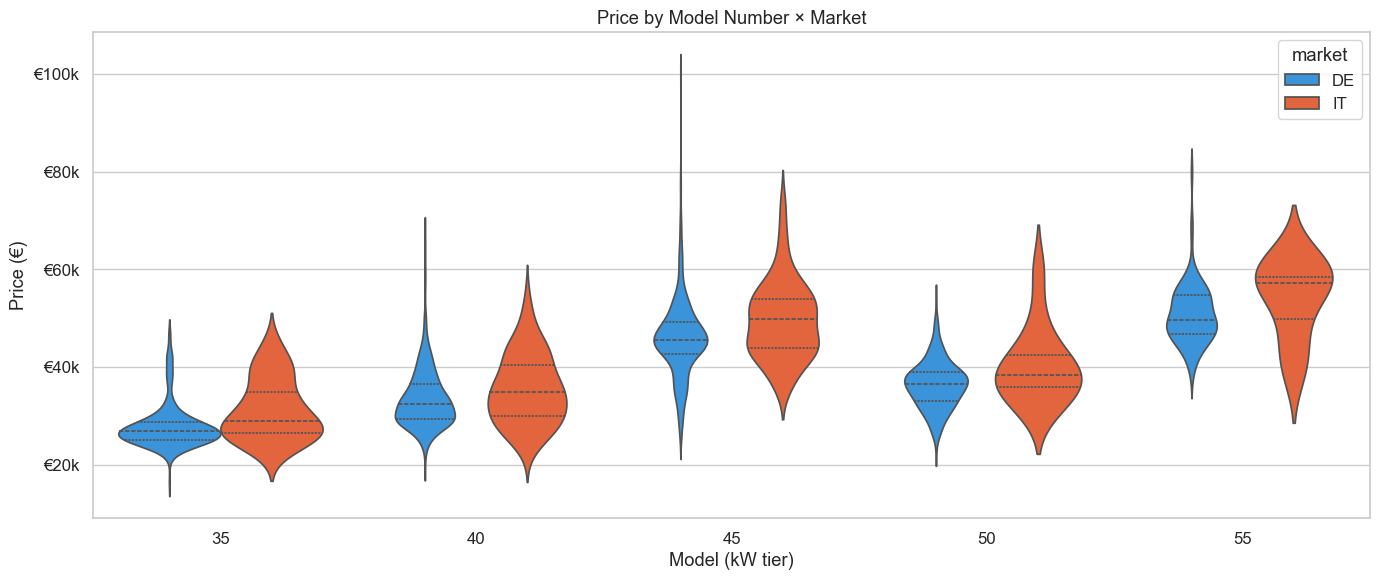

In [5]:
# Price by model_number_v2 × market
fig, ax = plt.subplots(figsize=(14, 6))

plot_data = df.dropna(subset=["price_eur", "model_number_v2"]).copy()
order = ["35", "40", "45", "50", "55"]
present_order = [m for m in order if m in plot_data["model_number_v2"].unique()]

sns.violinplot(data=plot_data, x="model_number_v2", y="price_eur",
               hue="market", order=present_order, palette=PALETTE,
               inner="quartile", split=False, ax=ax)
ax.set(title="Price by Model Number × Market",
       xlabel="Model (kW tier)", ylabel="Price (€)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"€{x/1000:.0f}k"))
plt.tight_layout()
plt.savefig("price_by_model_de_vs_it.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 4 — Model Mix & Trim Comparison

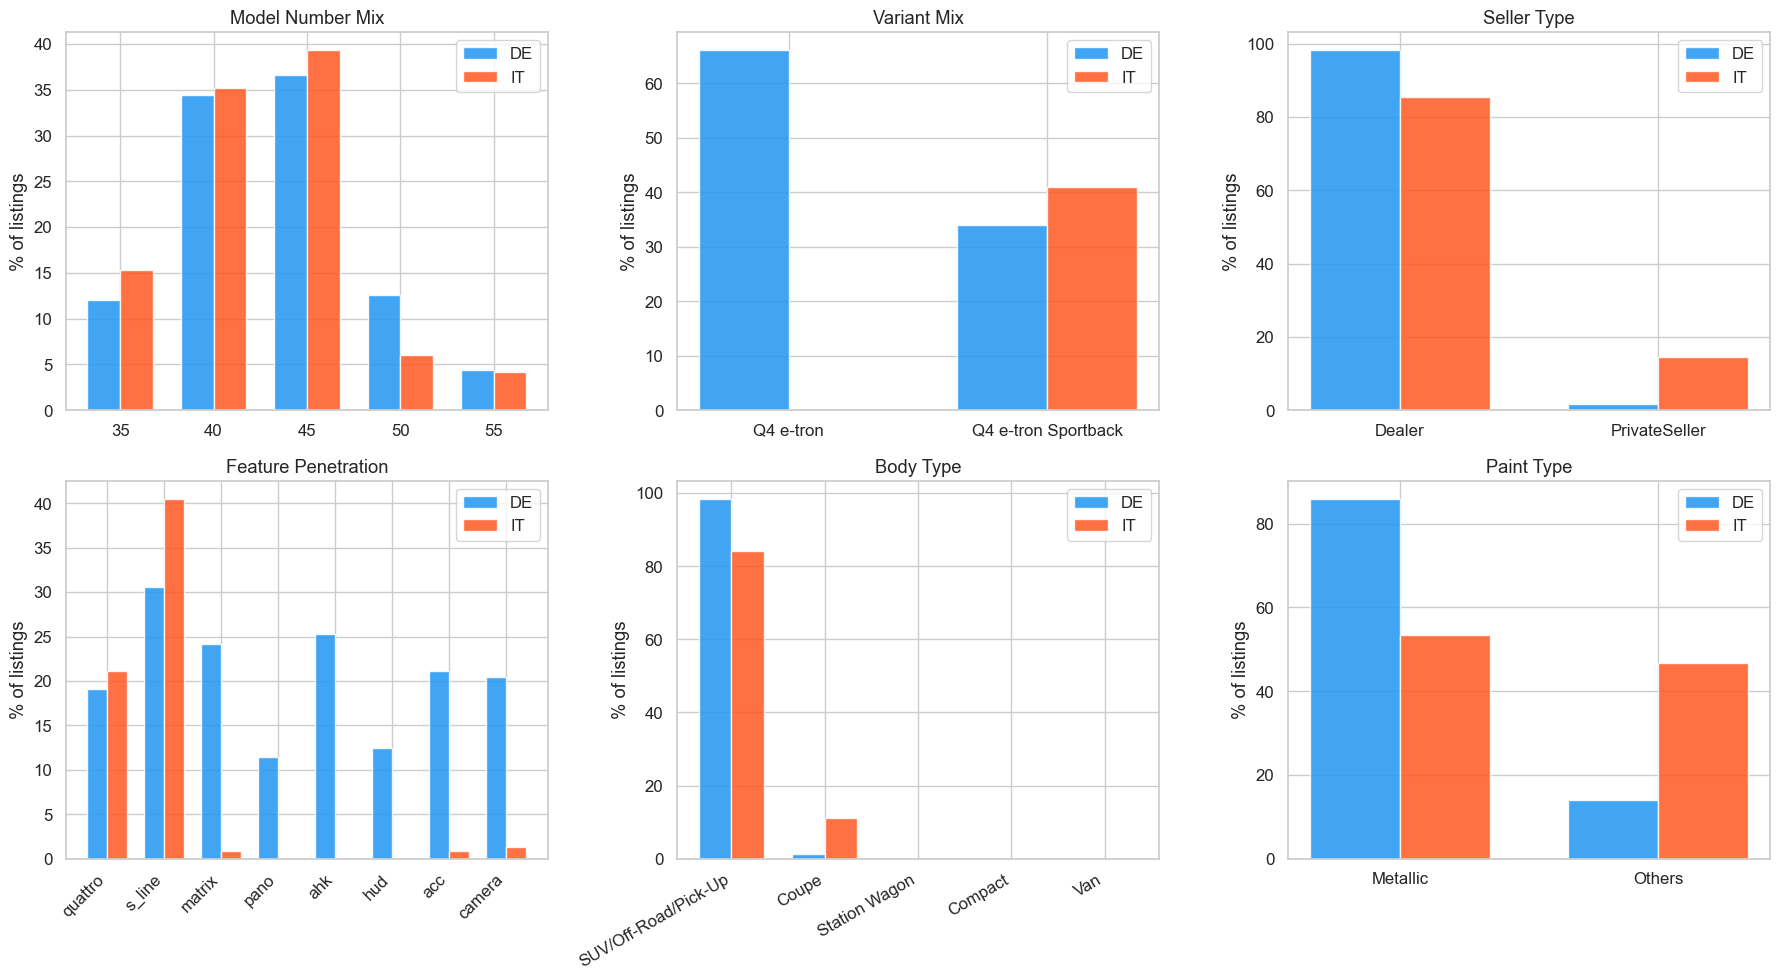

Saved: model_mix_de_vs_it.png


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

def side_by_side_bar(ax, col, title, order=None):
    de_vc = df_de_cs[col].value_counts(normalize=True) * 100
    it_vc = df_it_cs[col].value_counts(normalize=True) * 100
    if order is None:
        order = de_vc.index.tolist()
    de_vals = [de_vc.get(k, 0) for k in order]
    it_vals = [it_vc.get(k, 0) for k in order]
    x = np.arange(len(order))
    w = 0.35
    ax.bar(x - w/2, de_vals, w, label="DE", color=PALETTE["DE"], alpha=0.85)
    ax.bar(x + w/2, it_vals, w, label="IT", color=PALETTE["IT"], alpha=0.85)
    ax.set(title=title, xticks=x, xticklabels=order, ylabel="% of listings")
    ax.legend()

# Model number mix
side_by_side_bar(axes[0, 0], "model_number_v2", "Model Number Mix",
                 order=["35", "40", "45", "50", "55"])

# Variant (Sportback vs standard)
side_by_side_bar(axes[0, 1], "variant", "Variant Mix")

# Seller type
side_by_side_bar(axes[0, 2], "seller_type", "Seller Type")

# Feature penetration
feature_flags = ["is_quattro", "is_s_line", "has_matrix", "has_pano",
                 "has_ahk", "has_hud", "has_acc", "has_camera"]
de_feat = [df_de_cs[c].mean() * 100 for c in feature_flags]
it_feat = [df_it_cs[c].mean() * 100 for c in feature_flags]
x = np.arange(len(feature_flags))
w = 0.35
axes[1, 0].bar(x - w/2, de_feat, w, label="DE", color=PALETTE["DE"], alpha=0.85)
axes[1, 0].bar(x + w/2, it_feat, w, label="IT", color=PALETTE["IT"], alpha=0.85)
axes[1, 0].set(title="Feature Penetration",
               xticks=x, xticklabels=[c.replace("has_","").replace("is_","") for c in feature_flags],
               ylabel="% of listings")
axes[1, 0].legend()
plt.setp(axes[1, 0].xaxis.get_majorticklabels(), rotation=45, ha="right")

# Body type
side_by_side_bar(axes[1, 1], "body_type", "Body Type")
plt.setp(axes[1, 1].xaxis.get_majorticklabels(), rotation=30, ha="right")

# Paint type
side_by_side_bar(axes[1, 2], "paint_type", "Paint Type")

plt.tight_layout()
plt.savefig("model_mix_de_vs_it.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: model_mix_de_vs_it.png")

In [7]:
# Numeric feature penetration table
feature_flags = ["is_sportback", "is_quattro", "is_s_line", "has_matrix",
                 "has_pano", "has_ahk", "has_hud", "has_acc", "has_camera"]
feat_table = pd.DataFrame({
    "DE_%": [f"{df_de_cs[c].mean():.1%}" for c in feature_flags],
    "IT_%": [f"{df_it_cs[c].mean():.1%}" for c in feature_flags],
    "Diff (IT-DE pp)": [(df_it_cs[c].mean() - df_de_cs[c].mean()) * 100 for c in feature_flags],
}, index=feature_flags)
feat_table["Diff (IT-DE pp)"] = feat_table["Diff (IT-DE pp)"].map("{:+.1f}".format)
print(feat_table.to_string())
feat_table

               DE_%   IT_% Diff (IT-DE pp)
is_sportback  33.7%  36.1%            +2.4
is_quattro    19.1%  21.1%            +2.0
is_s_line     30.6%  40.5%            +9.9
has_matrix    24.2%   0.9%           -23.3
has_pano      11.4%   0.0%           -11.4
has_ahk       25.2%   0.0%           -25.2
has_hud       12.4%   0.0%           -12.4
has_acc       21.1%   0.9%           -20.3
has_camera    20.5%   1.3%           -19.2


,DE_%,IT_%,Diff (IT-DE pp)
is_sportback,33.7%,36.1%,+2.4
is_quattro,19.1%,21.1%,+2.0
is_s_line,30.6%,40.5%,+9.9
has_matrix,24.2%,0.9%,-23.3
has_pano,11.4%,0.0%,-11.4
has_ahk,25.2%,0.0%,-25.2
has_hud,12.4%,0.0%,-12.4
has_acc,21.1%,0.9%,-20.3
has_camera,20.5%,1.3%,-19.2


## Section 5 — Mileage & Age Comparison

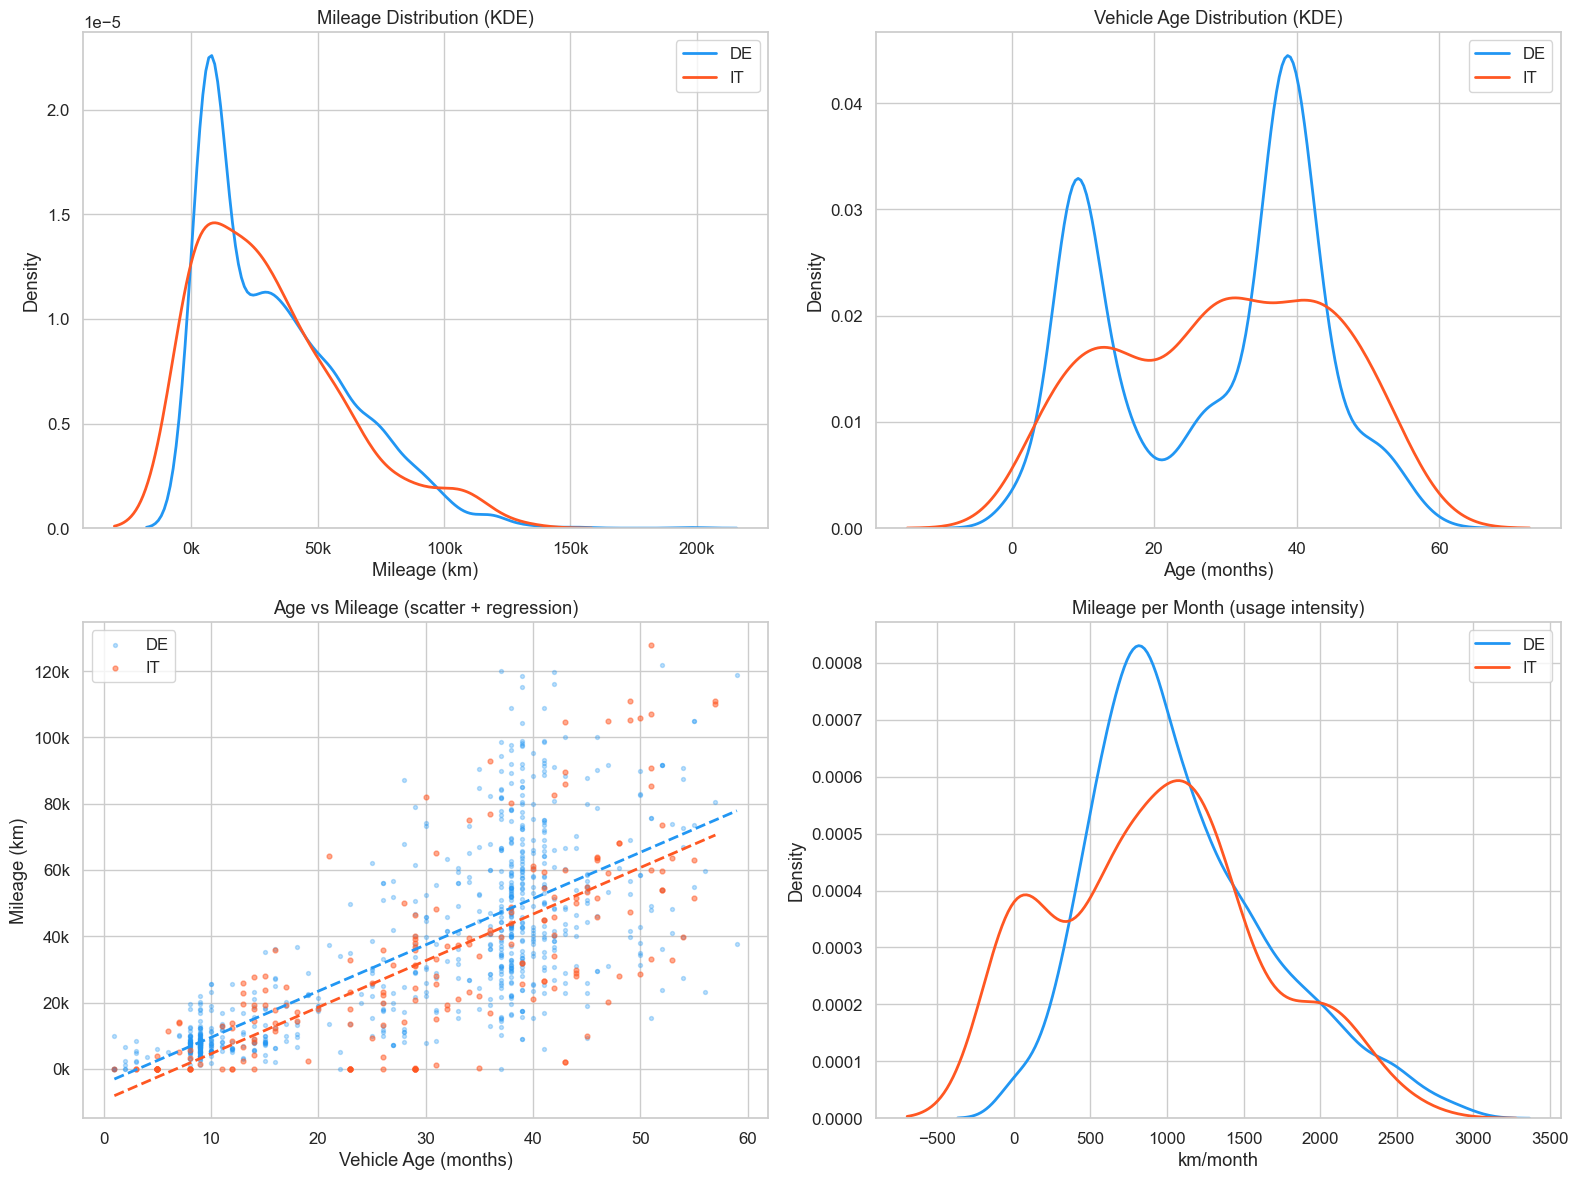

mileage_km: DE median=26934.5, IT median=25560.0, diff=-1374.5
vehicle_age_months: DE median=36.0, IT median=29.5, diff=-6.5
mileage_per_month: DE median=995.7, IT median=981.8, diff=-13.9


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Mileage KDE
for market, df_m in [("DE", df_de_cs), ("IT", df_it_cs)]:
    sns.kdeplot(df_m["mileage_km"].dropna(), ax=axes[0, 0],
                label=market, color=PALETTE[market], linewidth=2)
axes[0, 0].set(title="Mileage Distribution (KDE)", xlabel="Mileage (km)")
axes[0, 0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
axes[0, 0].legend()

# Vehicle age KDE
for market, df_m in [("DE", df_de_cs), ("IT", df_it_cs)]:
    sns.kdeplot(df_m["vehicle_age_months"].dropna(), ax=axes[0, 1],
                label=market, color=PALETTE[market], linewidth=2)
axes[0, 1].set(title="Vehicle Age Distribution (KDE)", xlabel="Age (months)")
axes[0, 1].legend()

# Age vs mileage scatter (sampled)
sample_de = df_de_cs.dropna(subset=["vehicle_age_months", "mileage_km"]).sample(
    min(800, len(df_de_cs)), random_state=42)
sample_it = df_it_cs.dropna(subset=["vehicle_age_months", "mileage_km"])
axes[1, 0].scatter(sample_de["vehicle_age_months"], sample_de["mileage_km"],
                   alpha=0.3, s=8, color=PALETTE["DE"], label="DE")
axes[1, 0].scatter(sample_it["vehicle_age_months"], sample_it["mileage_km"],
                   alpha=0.5, s=12, color=PALETTE["IT"], label="IT")
# Regression lines
for df_m, color, label in [(sample_de, PALETTE["DE"], "DE"), (sample_it, PALETTE["IT"], "IT")]:
    valid = df_m.dropna(subset=["vehicle_age_months", "mileage_km"])
    if len(valid) > 5:
        m, b, *_ = stats.linregress(valid["vehicle_age_months"], valid["mileage_km"])
        x_range = np.linspace(valid["vehicle_age_months"].min(), valid["vehicle_age_months"].max(), 100)
        axes[1, 0].plot(x_range, m * x_range + b, color=color, linewidth=2, linestyle="--")
axes[1, 0].set(title="Age vs Mileage (scatter + regression)",
               xlabel="Vehicle Age (months)", ylabel="Mileage (km)")
axes[1, 0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
axes[1, 0].legend()

# Mileage per month KDE
for market, df_m in [("DE", df_de_cs), ("IT", df_it_cs)]:
    val = df_m["mileage_per_month"].dropna()
    val = val[val < val.quantile(0.99)]
    sns.kdeplot(val, ax=axes[1, 1], label=market, color=PALETTE[market], linewidth=2)
axes[1, 1].set(title="Mileage per Month (usage intensity)", xlabel="km/month")
axes[1, 1].legend()

plt.tight_layout()
plt.savefig("mileage_age_de_vs_it.png", dpi=150, bbox_inches="tight")
plt.show()

# Summary stats
for col in ["mileage_km", "vehicle_age_months", "mileage_per_month"]:
    de_val = df_de_cs[col].median()
    it_val = df_it_cs[col].median()
    print(f"{col}: DE median={de_val:.1f}, IT median={it_val:.1f}, diff={it_val-de_val:+.1f}")

## Section 6 — Seller Profile Comparison

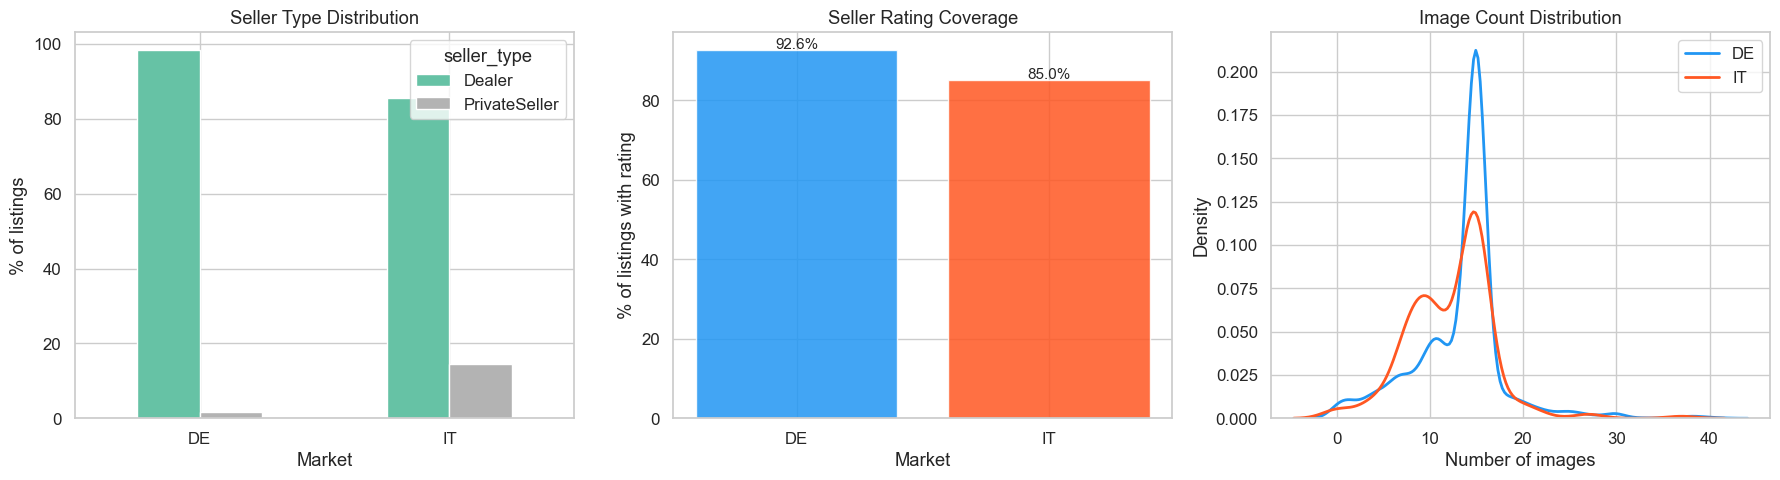

seller_rating_stars: DE=4.50, IT=4.50
image_count: DE=15.00, IT=14.00
previous_owner_count: DE=1.00, IT=1.00


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Seller type stacked bar
seller_counts = df.groupby(["market", "seller_type"]).size().unstack(fill_value=0)
seller_pct = seller_counts.div(seller_counts.sum(axis=1), axis=0) * 100
seller_pct.plot(kind="bar", ax=axes[0], colormap="Set2", edgecolor="white")
axes[0].set(title="Seller Type Distribution", xlabel="Market", ylabel="% of listings")
axes[0].tick_params(axis="x", rotation=0)

# Seller rating coverage
rating_cov = df.groupby("market")["seller_has_rating"].mean() * 100
axes[1].bar(rating_cov.index, rating_cov.values,
            color=[PALETTE[m] for m in rating_cov.index], alpha=0.85)
axes[1].set(title="Seller Rating Coverage", xlabel="Market", ylabel="% of listings with rating")
for i, (m, v) in enumerate(rating_cov.items()):
    axes[1].text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=11)

# Image count distribution
for market, df_m in [("DE", df_de_cs), ("IT", df_it_cs)]:
    img_cnt = df_m["image_count"].dropna()
    sns.kdeplot(img_cnt, ax=axes[2], label=market, color=PALETTE[market], linewidth=2)
axes[2].set(title="Image Count Distribution", xlabel="Number of images")
axes[2].legend()

plt.tight_layout()
plt.savefig("seller_profile_de_vs_it.png", dpi=150, bbox_inches="tight")
plt.show()

# Numeric summary
for col in ["seller_rating_stars", "image_count", "previous_owner_count"]:
    de_val = df_de_cs[col].median()
    it_val = df_it_cs[col].median()
    print(f"{col}: DE={de_val:.2f}, IT={it_val:.2f}")

## Section 7 — Feature Completeness & Data Quality

                                DE_missing_%  IT_missing_%  diff (IT-DE pp)
electric_range_km                        3.0          63.4             60.4
previous_owner_count                     5.5          44.1             38.6
interior_color                           3.5          41.9             38.4
mileage_km                               0.1          13.2             13.1
vehicle_age_months                       2.8          15.4             12.6
seller_rating_stars                      7.4          15.0              7.6
exterior_color                           1.9           6.6              4.7
battery_charging_time_min               94.4          98.7              4.3
has_full_service_history_clean           1.5           3.5              2.0
price_eur                                0.0           0.0              0.0
power_kw                                 0.1           0.0             -0.1
body_type                                1.5           0.0             -1.5
had_accident

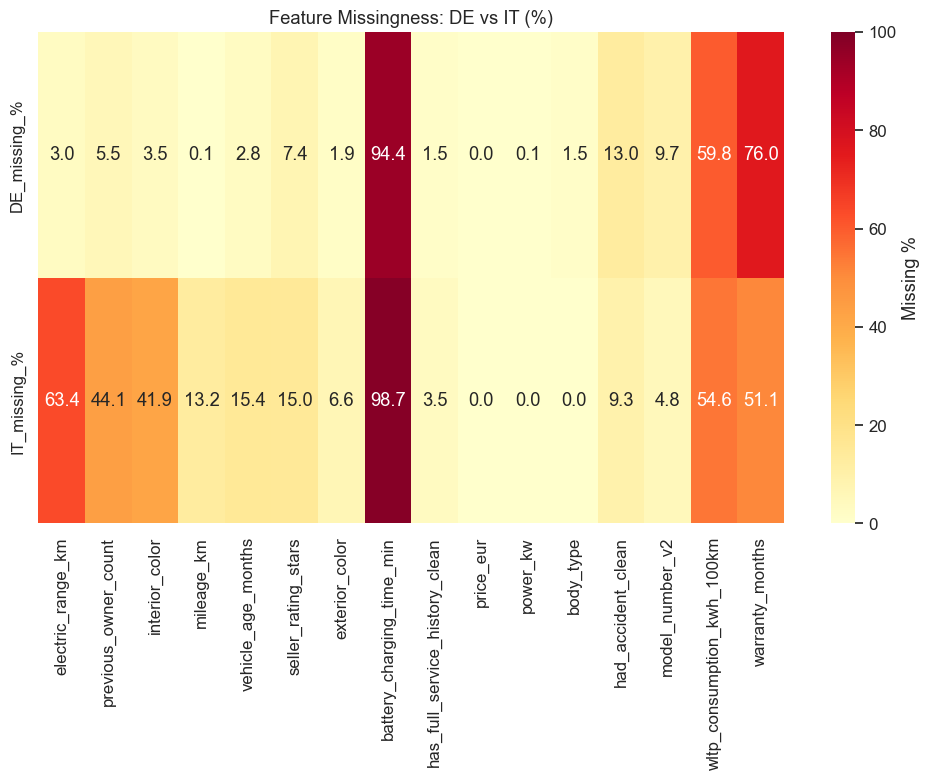

,DE_missing_%,IT_missing_%,diff (IT-DE pp)
electric_range_km,3.0,63.4,60.4
previous_owner_count,5.5,44.1,38.6
interior_color,3.5,41.9,38.4
mileage_km,0.1,13.2,13.1
vehicle_age_months,2.8,15.4,12.6
seller_rating_stars,7.4,15.0,7.6
exterior_color,1.9,6.6,4.7
battery_charging_time_min,94.4,98.7,4.3
has_full_service_history_clean,1.5,3.5,2.0
price_eur,0.0,0.0,0.0


In [10]:
# Missingness comparison
key_cols = [
    "price_eur", "mileage_km", "vehicle_age_months", "power_kw",
    "electric_range_km", "wltp_consumption_kwh_100km",
    "model_number_v2", "body_type", "exterior_color", "interior_color",
    "warranty_months", "battery_charging_time_min",
    "previous_owner_count", "seller_rating_stars",
    "had_accident_clean", "has_full_service_history_clean",
]
key_cols = [c for c in key_cols if c in df_de_cs.columns and c in df_it_cs.columns]

missing_df = pd.DataFrame({
    "DE_missing_%": (df_de_cs[key_cols].isna().mean() * 100).round(1),
    "IT_missing_%": (df_it_cs[key_cols].isna().mean() * 100).round(1),
})
missing_df["diff (IT-DE pp)"] = (missing_df["IT_missing_%"] - missing_df["DE_missing_%"]).round(1)
missing_df = missing_df.sort_values("diff (IT-DE pp)", ascending=False)
print(missing_df.to_string())

# Heatmap
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    missing_df[["DE_missing_%", "IT_missing_%"]].T,
    annot=True, fmt=".1f", cmap="YlOrRd", vmin=0, vmax=100,
    cbar_kws={"label": "Missing %"}, ax=ax
)
ax.set_title("Feature Missingness: DE vs IT (%)")
plt.tight_layout()
plt.savefig("missingness_de_vs_it.png", dpi=150, bbox_inches="tight")
plt.show()

missing_df

## Section 8 — Price Driver Correlation Comparison

                            DE_rho  IT_rho
feature                                   
vehicle_age_months          -0.795  -0.845
mileage_km                  -0.770  -0.821
mileage_per_month           -0.361  -0.530
image_count                 -0.170  -0.124
wltp_consumption_kwh_100km  -0.136  -0.217
previous_owner_count        -0.084  -0.264
seller_rating_stars          0.011  -0.234
electric_range_km            0.386   0.388
power_kw                     0.638   0.233
power_hp                     0.638   0.233
warranty_months              0.656   0.511

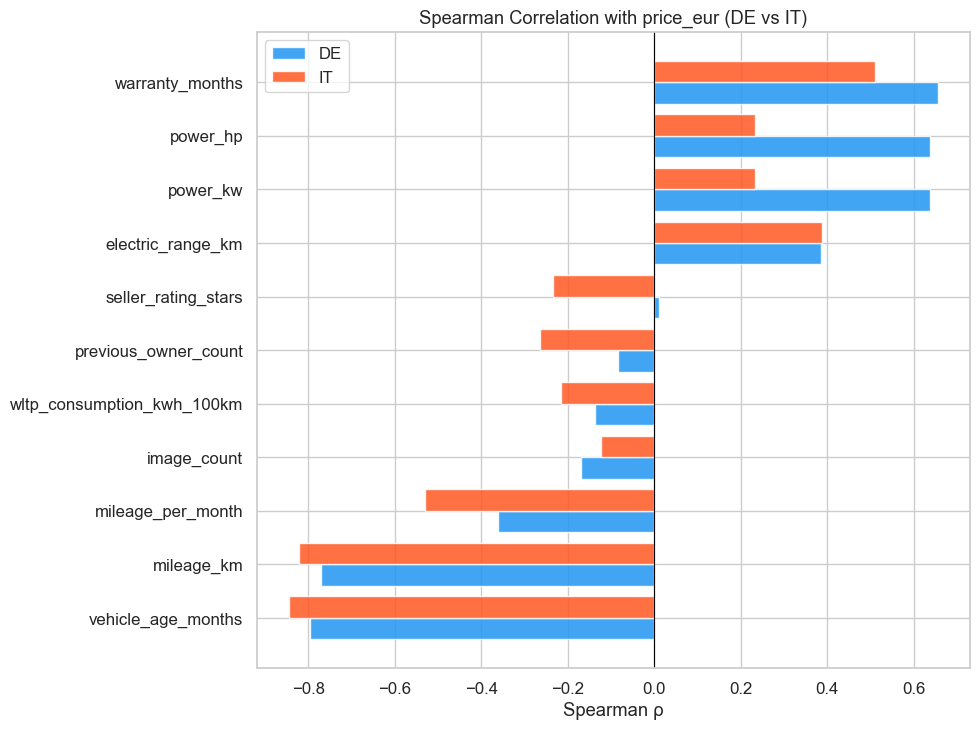

,DE_rho,IT_rho
feature,,
vehicle_age_months,-0.795047,-0.844738
mileage_km,-0.770164,-0.820595
mileage_per_month,-0.361166,-0.530026
image_count,-0.169650,-0.123669
wltp_consumption_kwh_100km,-0.136332,-0.216527
previous_owner_count,-0.084297,-0.264411
seller_rating_stars,0.011088,-0.234431
electric_range_km,0.386084,0.388072
power_kw,0.637589,0.232591


In [11]:
numeric_cols_for_corr = [
    "mileage_km", "vehicle_age_months", "power_kw", "power_hp",
    "electric_range_km", "wltp_consumption_kwh_100km",
    "seller_rating_stars", "image_count", "previous_owner_count",
    "warranty_months", "mileage_per_month",
]
numeric_cols_for_corr = [c for c in numeric_cols_for_corr
                         if c in df_de_cs.columns and c in df_it_cs.columns]

corr_results = []
for col in numeric_cols_for_corr:
    de_valid = df_de_cs[[col, "price_eur"]].dropna()
    it_valid = df_it_cs[[col, "price_eur"]].dropna()
    de_rho = de_valid.corr(method="spearman").loc[col, "price_eur"] if len(de_valid) > 10 else np.nan
    it_rho = it_valid.corr(method="spearman").loc[col, "price_eur"] if len(it_valid) > 10 else np.nan
    corr_results.append({"feature": col, "DE_rho": de_rho, "IT_rho": it_rho})

corr_df = pd.DataFrame(corr_results).set_index("feature").sort_values("DE_rho", ascending=True)
print(corr_df.round(3).to_string())

# Side-by-side horizontal bar chart
fig, ax = plt.subplots(figsize=(10, len(corr_df) * 0.5 + 2))
y = np.arange(len(corr_df))
ax.barh(y - 0.2, corr_df["DE_rho"], 0.4, label="DE", color=PALETTE["DE"], alpha=0.85)
ax.barh(y + 0.2, corr_df["IT_rho"], 0.4, label="IT", color=PALETTE["IT"], alpha=0.85)
ax.set(yticks=y, yticklabels=corr_df.index,
       title="Spearman Correlation with price_eur (DE vs IT)",
       xlabel="Spearman ρ")
ax.axvline(0, color="black", linewidth=0.8)
ax.legend()
plt.tight_layout()
plt.savefig("price_correlations_de_vs_it.png", dpi=150, bbox_inches="tight")
plt.show()
corr_df

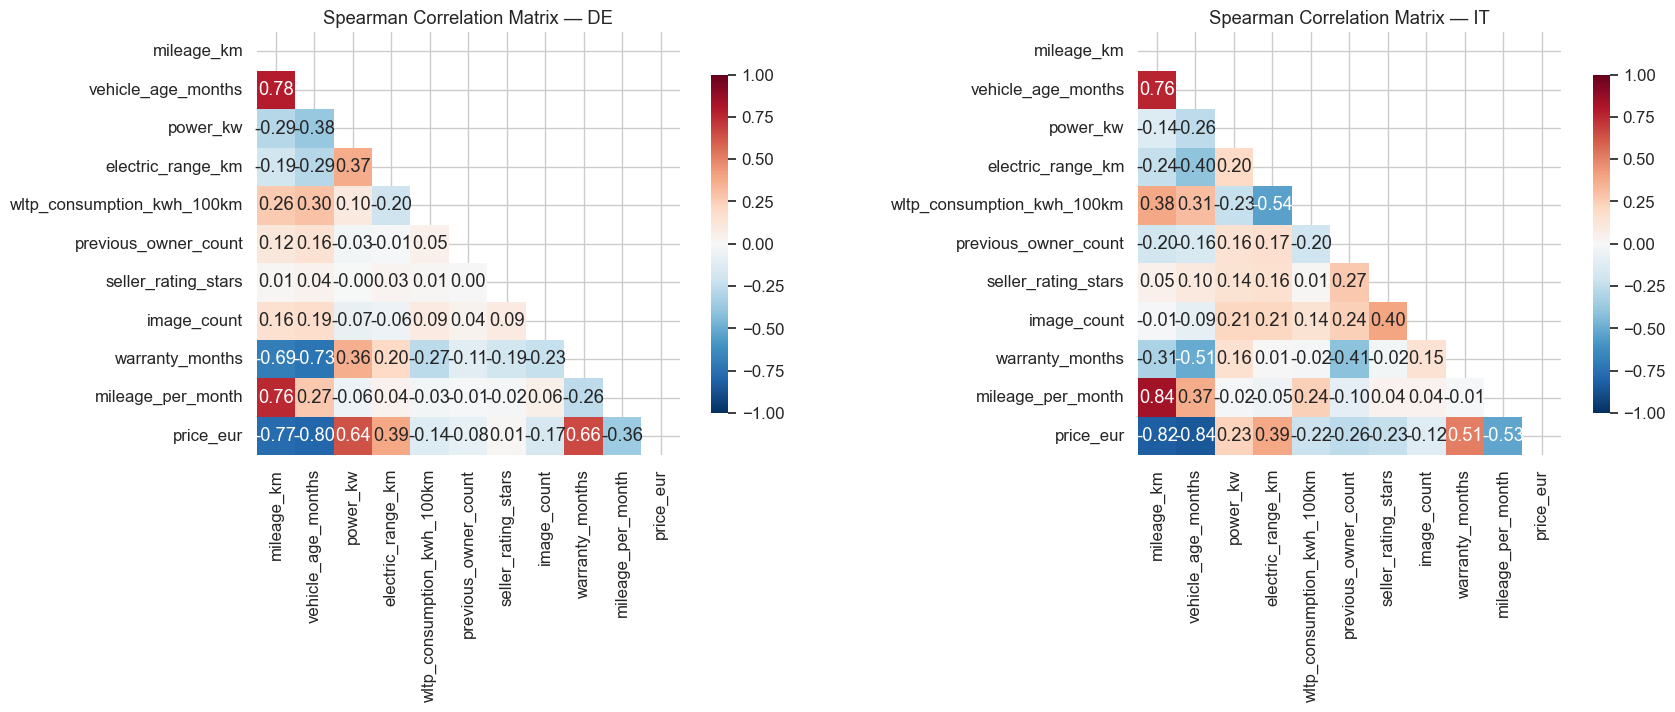

In [12]:
# Top 10 numeric feature correlation matrix, DE vs IT side-by-side
top10 = [c for c in ["mileage_km", "vehicle_age_months", "power_kw", "electric_range_km",
                      "wltp_consumption_kwh_100km", "previous_owner_count",
                      "seller_rating_stars", "image_count", "warranty_months", "mileage_per_month"]
         if c in df_de_cs.columns and c in df_it_cs.columns]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, (market, df_m) in zip(axes, [("DE", df_de_cs), ("IT", df_it_cs)]):
    corr_matrix = df_m[top10 + ["price_eur"]].corr(method="spearman")
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
                vmin=-1, vmax=1, ax=ax, square=True,
                cbar_kws={"shrink": 0.8})
    ax.set_title(f"Spearman Correlation Matrix — {market}")

plt.tight_layout()
plt.savefig("corr_matrix_de_vs_it.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 9 — Cross-Market Price Positioning

Apply the DE-trained price model to Italy listings to quantify the market gap.
A positive `de_vs_it_gap_eur` means the DE model predicts a **higher** price than
the Italian asking price — i.e., the listing appears cheap relative to German market value.

In [13]:
import json

if not PRICE_MODEL_PATH.exists():
    print(f"Price model not found at {PRICE_MODEL_PATH}. Skipping Section 9.")
    PRICE_MODEL_LOADED = False
else:
    price_model_de = joblib.load(PRICE_MODEL_PATH)

    with open(PRICE_META_PATH) as f:
        price_meta = json.load(f)

    USE_LOG_TARGET    = price_meta.get("use_log_target", False)
    PRICE_FEATURE_COLS = price_meta.get("feature_cols", [])

    available_feat = [c for c in PRICE_FEATURE_COLS if c in df_it_cs.columns]
    missing_feat   = [c for c in PRICE_FEATURE_COLS if c not in df_it_cs.columns]

    if missing_feat:
        print(f"Missing features in IT dataset (will be NaN-filled): {missing_feat}")
        for c in missing_feat:
            df_it_cs[c] = np.nan

    PRICE_MODEL_LOADED = True
    print(f"Loaded DE price model ({price_meta.get('best_model_name')}). "
          f"use_log_target={USE_LOG_TARGET}")
    print(f"Feature set: {len(PRICE_FEATURE_COLS)} columns")

Loaded DE price model (LightGBM). use_log_target=True
Feature set: 42 columns


In [14]:
if PRICE_MODEL_LOADED:
    X_it = df_it_cs[PRICE_FEATURE_COLS].copy()

    # Boolean columns to int (pipeline expects numeric input for binary features)
    bool_cols_in_feat = X_it.select_dtypes(include=["bool", "boolean"]).columns
    X_it[bool_cols_in_feat] = X_it[bool_cols_in_feat].astype(float)

    raw_pred = price_model_de.predict(X_it)
    if USE_LOG_TARGET:
        df_it_cs["de_model_predicted_price"] = np.expm1(raw_pred)
    else:
        df_it_cs["de_model_predicted_price"] = raw_pred

    df_it_cs["de_vs_it_gap_eur"] = (
        df_it_cs["de_model_predicted_price"] - df_it_cs["price_eur"]
    )
    df_it_cs["de_vs_it_gap_pct"] = (
        df_it_cs["de_vs_it_gap_eur"] / df_it_cs["de_model_predicted_price"] * 100
    )

    print("Gap summary (DE model predicted price − IT asking price):")
    gap = df_it_cs["de_vs_it_gap_eur"].dropna()
    print(f"  Mean gap:   €{gap.mean():,.0f}")
    print(f"  Median gap: €{gap.median():,.0f}")
    print(f"  Std:        €{gap.std():,.0f}")
    print(f"  % listings with positive gap (IT cheaper than DE): {(gap > 0).mean():.1%}")
    print(f"  % listings with gap >€2,000: {(gap > 2000).mean():.1%}")

Gap summary (DE model predicted price − IT asking price):
  Mean gap:   €-5,987
  Median gap: €-4,573
  Std:        €7,188
  % listings with positive gap (IT cheaper than DE): 20.3%
  % listings with gap >€2,000: 5.7%


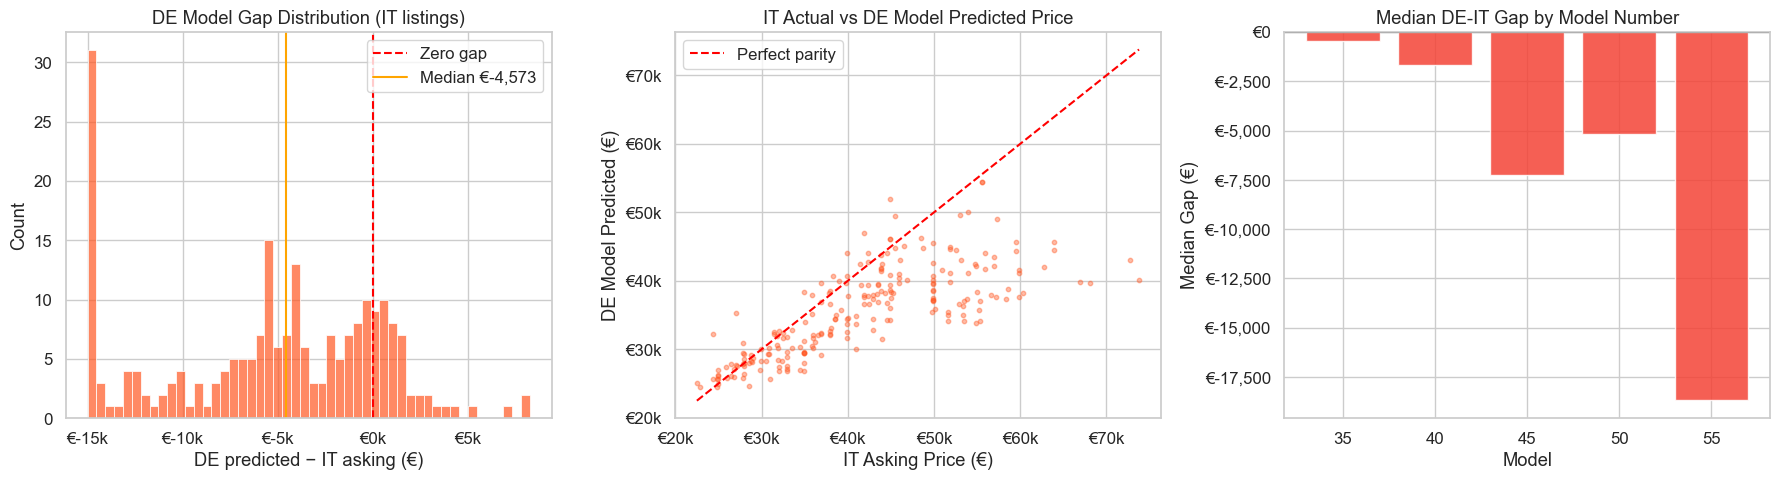

In [15]:
if PRICE_MODEL_LOADED:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Gap distribution
    gap = df_it_cs["de_vs_it_gap_eur"].dropna()
    gap_clipped = gap.clip(-15000, 15000)
    sns.histplot(gap_clipped, bins=50, ax=axes[0], color=PALETTE["IT"], alpha=0.7)
    axes[0].axvline(0, color="red", linewidth=1.5, linestyle="--", label="Zero gap")
    axes[0].axvline(gap.median(), color="orange", linewidth=1.5,
                    linestyle="-", label=f"Median €{gap.median():,.0f}")
    axes[0].set(title="DE Model Gap Distribution (IT listings)",
                xlabel="DE predicted − IT asking (€)")
    axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"€{x/1000:.0f}k"))
    axes[0].legend()

    # Predicted vs actual scatter
    valid_pred = df_it_cs.dropna(subset=["price_eur", "de_model_predicted_price"])
    axes[1].scatter(valid_pred["price_eur"], valid_pred["de_model_predicted_price"],
                    alpha=0.4, s=10, color=PALETTE["IT"])
    min_v = min(valid_pred["price_eur"].min(), valid_pred["de_model_predicted_price"].min())
    max_v = max(valid_pred["price_eur"].max(), valid_pred["de_model_predicted_price"].max())
    axes[1].plot([min_v, max_v], [min_v, max_v], "r--", linewidth=1.5, label="Perfect parity")
    axes[1].set(title="IT Actual vs DE Model Predicted Price",
                xlabel="IT Asking Price (€)", ylabel="DE Model Predicted (€)")
    axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"€{x/1000:.0f}k"))
    axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"€{x/1000:.0f}k"))
    axes[1].legend()

    # Gap by model_number_v2
    gap_by_model = df_it_cs.groupby("model_number_v2")["de_vs_it_gap_eur"].median().sort_index()
    colors_bar = ["#4CAF50" if v > 0 else "#F44336" for v in gap_by_model.values]
    axes[2].bar(gap_by_model.index, gap_by_model.values, color=colors_bar, alpha=0.85)
    axes[2].axhline(0, color="black", linewidth=0.8)
    axes[2].set(title="Median DE-IT Gap by Model Number",
                xlabel="Model", ylabel="Median Gap (€)")
    axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"€{x:,.0f}"))

    plt.tight_layout()
    plt.savefig("cross_market_gap_de_vs_it.png", dpi=150, bbox_inches="tight")
    plt.show()

In [16]:
if PRICE_MODEL_LOADED:
    print("\n--- Top 20 Italy listings cheapest vs DE market model ---")
    top_gaps = (
        df_it_cs[df_it_cs["de_vs_it_gap_eur"] > 500]
        .sort_values("de_vs_it_gap_eur", ascending=False)
        .head(20)
    )
    display_cols = ["title", "price_eur", "de_model_predicted_price",
                    "de_vs_it_gap_eur", "de_vs_it_gap_pct",
                    "model_number_v2", "variant", "mileage_km",
                    "vehicle_age_months", "city"]
    display_cols = [c for c in display_cols if c in top_gaps.columns]

    pd.set_option("display.float_format", "{:,.0f}".format)
    print(top_gaps[display_cols].to_string(index=False))
    top_gaps[display_cols]


--- Top 20 Italy listings cheapest vs DE market model ---
                                                                          title  price_eur  de_model_predicted_price  de_vs_it_gap_eur  de_vs_it_gap_pct model_number_v2             variant  mileage_km  vehicle_age_months                             city
                 Audi Q4 e-tron Q4 Sportback e-tron Sportback 35 S line edition      27000                    35,270             8,270                23              35 Q4 e-tron Sportback       37500                  33                          Lomazzo
                                          Audi Q4 e-tron Q4 Sportback e-tron 40      24400                    32,210             7,810                24              40 Q4 e-tron Sportback       32790                  53         San Giovanni Battista GE
Audi Q4 e-tron Q4 Sportback Spb e-tron 45 S line S-line Sline Edition NUOVA KM0      44900                    51,974             7,074                14              45 Q4 e-tron 

## Section 10 — Summary Dashboard

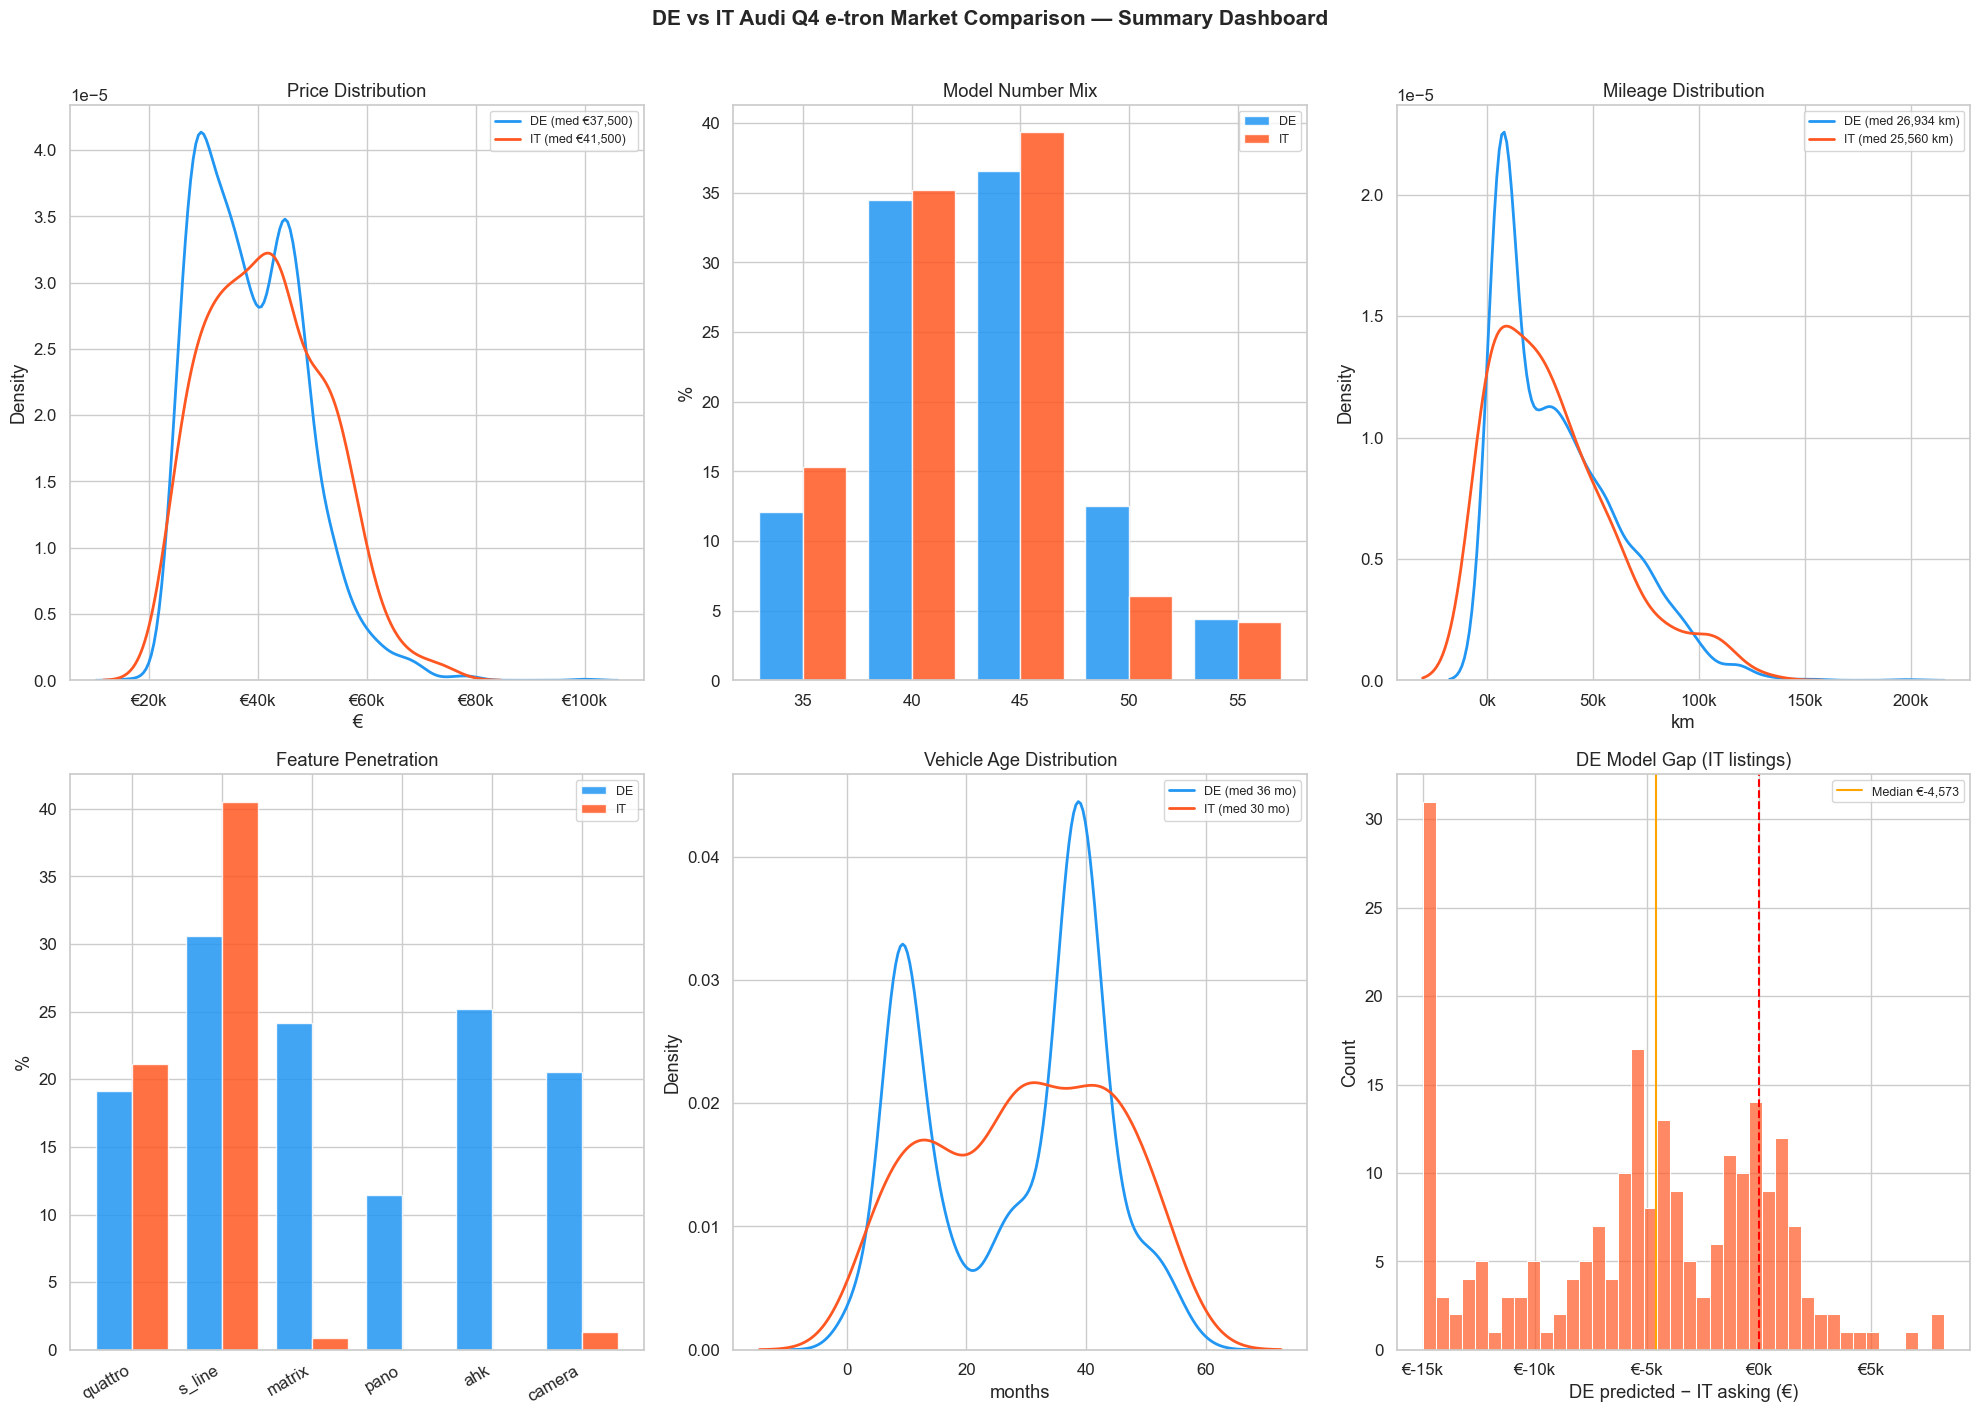

Saved: summary_dashboard_de_vs_it.png


In [17]:
fig = plt.figure(figsize=(20, 14))
fig.suptitle("DE vs IT Audi Q4 e-tron Market Comparison — Summary Dashboard",
             fontsize=15, fontweight="bold", y=1.01)

ax1 = fig.add_subplot(2, 3, 1)
ax2 = fig.add_subplot(2, 3, 2)
ax3 = fig.add_subplot(2, 3, 3)
ax4 = fig.add_subplot(2, 3, 4)
ax5 = fig.add_subplot(2, 3, 5)
ax6 = fig.add_subplot(2, 3, 6)

# 1. Price KDE
for market, df_m in [("DE", df_de_cs), ("IT", df_it_cs)]:
    sns.kdeplot(df_m["price_eur"].dropna(), ax=ax1,
                label=f"{market} (med €{df_m['price_eur'].median():,.0f})",
                color=PALETTE[market], linewidth=2)
ax1.set(title="Price Distribution", xlabel="€")
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"€{x/1000:.0f}k"))
ax1.legend(fontsize=9)

# 2. Model mix
model_order = ["35", "40", "45", "50", "55"]
de_model = [df_de_cs["model_number_v2"].value_counts(normalize=True).get(m, 0)*100 for m in model_order]
it_model = [df_it_cs["model_number_v2"].value_counts(normalize=True).get(m, 0)*100 for m in model_order]
x = np.arange(len(model_order))
ax2.bar(x - 0.2, de_model, 0.4, label="DE", color=PALETTE["DE"], alpha=0.85)
ax2.bar(x + 0.2, it_model, 0.4, label="IT", color=PALETTE["IT"], alpha=0.85)
ax2.set(title="Model Number Mix", xticks=x, xticklabels=model_order, ylabel="%")
ax2.legend(fontsize=9)

# 3. Mileage KDE
for market, df_m in [("DE", df_de_cs), ("IT", df_it_cs)]:
    sns.kdeplot(df_m["mileage_km"].dropna(), ax=ax3,
                label=f"{market} (med {df_m['mileage_km'].median():,.0f} km)",
                color=PALETTE[market], linewidth=2)
ax3.set(title="Mileage Distribution", xlabel="km")
ax3.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
ax3.legend(fontsize=9)

# 4. Feature penetration
features = ["is_quattro", "is_s_line", "has_matrix", "has_pano", "has_ahk", "has_camera"]
f_labels = [c.replace("is_","").replace("has_","") for c in features]
de_f = [df_de_cs[c].mean()*100 for c in features]
it_f = [df_it_cs[c].mean()*100 for c in features]
x = np.arange(len(features))
ax4.bar(x - 0.2, de_f, 0.4, label="DE", color=PALETTE["DE"], alpha=0.85)
ax4.bar(x + 0.2, it_f, 0.4, label="IT", color=PALETTE["IT"], alpha=0.85)
ax4.set(title="Feature Penetration", xticks=x, xticklabels=f_labels, ylabel="%")
plt.setp(ax4.xaxis.get_majorticklabels(), rotation=30, ha="right")
ax4.legend(fontsize=9)

# 5. Age KDE
for market, df_m in [("DE", df_de_cs), ("IT", df_it_cs)]:
    sns.kdeplot(df_m["vehicle_age_months"].dropna(), ax=ax5,
                label=f"{market} (med {df_m['vehicle_age_months'].median():.0f} mo)",
                color=PALETTE[market], linewidth=2)
ax5.set(title="Vehicle Age Distribution", xlabel="months")
ax5.legend(fontsize=9)

# 6. Gap distribution (if model loaded) or price box plot
if PRICE_MODEL_LOADED and "de_vs_it_gap_eur" in df_it_cs.columns:
    gap = df_it_cs["de_vs_it_gap_eur"].dropna()
    gap_clipped = gap.clip(-15000, 15000)
    sns.histplot(gap_clipped, bins=40, ax=ax6, color=PALETTE["IT"], alpha=0.7)
    ax6.axvline(0, color="red", linewidth=1.5, linestyle="--")
    ax6.axvline(gap.median(), color="orange", linewidth=1.5,
                label=f"Median €{gap.median():,.0f}")
    ax6.set(title="DE Model Gap (IT listings)", xlabel="DE predicted − IT asking (€)")
    ax6.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"€{x/1000:.0f}k"))
    ax6.legend(fontsize=9)
else:
    df_price_box = df[["price_eur", "market"]].dropna()
    sns.boxplot(data=df_price_box, x="market", y="price_eur", palette=PALETTE, ax=ax6)
    ax6.set(title="Price Box Plot", xlabel="Market", ylabel="€")
    ax6.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"€{x/1000:.0f}k"))

plt.tight_layout()
plt.savefig("summary_dashboard_de_vs_it.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: summary_dashboard_de_vs_it.png")

In [18]:
print("=" * 60)
print("DE vs IT COMPARISON — KEY FINDINGS")
print("=" * 60)
print(f"\nMarket sizes: DE={len(df_de_cs):,} listings | IT={len(df_it_cs):,} listings")
print(f"\nPRICE")
print(f"  DE median: €{df_de_cs['price_eur'].median():,.0f}")
print(f"  IT median: €{df_it_cs['price_eur'].median():,.0f}")
price_delta = df_it_cs['price_eur'].median() - df_de_cs['price_eur'].median()
print(f"  Delta: {price_delta:+,.0f} (IT {'higher' if price_delta > 0 else 'lower'} by {abs(price_delta/df_de_cs['price_eur'].median()):.1%})")
print(f"\nMILEAGE")
print(f"  DE median: {df_de_cs['mileage_km'].median():,.0f} km")
print(f"  IT median: {df_it_cs['mileage_km'].median():,.0f} km")
print(f"\nAGE")
print(f"  DE median: {df_de_cs['vehicle_age_months'].median():.0f} months")
print(f"  IT median: {df_it_cs['vehicle_age_months'].median():.0f} months")
print(f"\nMODEL MIX (most common)")
print(f"  DE: {df_de_cs['model_number_v2'].value_counts().index[0]} ({df_de_cs['model_number_v2'].value_counts(normalize=True).iloc[0]:.1%})")
print(f"  IT: {df_it_cs['model_number_v2'].value_counts().index[0]} ({df_it_cs['model_number_v2'].value_counts(normalize=True).iloc[0]:.1%})")
print(f"\nSPORTBACK SHARE")
print(f"  DE: {df_de_cs['is_sportback'].mean():.1%}  |  IT: {df_it_cs['is_sportback'].mean():.1%}")
if PRICE_MODEL_LOADED and "de_vs_it_gap_eur" in df_it_cs.columns:
    gap = df_it_cs["de_vs_it_gap_eur"].dropna()
    print(f"\nCROSS-MARKET PRICE GAP (DE model vs IT asking)")
    print(f"  Median gap: €{gap.median():+,.0f}  (positive = IT cheaper vs DE model)")
    print(f"  Listings with gap > €2,000: {(gap > 2000).sum()} ({(gap > 2000).mean():.1%})")
print("=" * 60)

DE vs IT COMPARISON — KEY FINDINGS

Market sizes: DE=2,517 listings | IT=227 listings

PRICE
  DE median: €37,500
  IT median: €41,500
  Delta: +4,000 (IT higher by 10.7%)

MILEAGE
  DE median: 26,934 km
  IT median: 25,560 km

AGE
  DE median: 36 months
  IT median: 30 months

MODEL MIX (most common)
  DE: 45 (36.6%)
  IT: 45 (39.4%)

SPORTBACK SHARE
  DE: 33.7%  |  IT: 36.1%

CROSS-MARKET PRICE GAP (DE model vs IT asking)
  Median gap: €-4,573  (positive = IT cheaper vs DE model)
  Listings with gap > €2,000: 13 (5.7%)
